### Importação das Biblio

In [3]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

### Preparação de Dados

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Carregamento e Limpeza Padrão ---
df = pd.read_csv('student_performance_large_dataset.csv')
df.drop(columns=['Student_ID', 'Final_Grade', 'Gender'], inplace=True)
df.columns = df.columns.str.lower().str.replace(' ', '_', regex=False).str.replace(r'[^a-zA-Z0-9_]', '', regex=True)
df.dropna(inplace=True)

# --- Engenharia de Features Avançada ---
# Vamos criar uma nova feature: a razão entre a conclusão de tarefas e as horas de estudo.
# Isso pode indicar a "eficiência" do aluno. Adicionamos 1 para evitar divisão por zero.
df['assignment_study_ratio'] = df['assignment_completion_rate_'] / (df['study_hours_per_week'] + 1)
print("Nova feature 'assignment_study_ratio' criada.")

# --- Encoding e Definição de Alvo ---
colunas_de_texto = ['preferred_learning_style', 'use_of_educational_tech', 'participation_in_discussions', 'self_reported_stress_level']
df = pd.get_dummies(df, columns=colunas_de_texto, drop_first=True)

nota_de_corte = 60
df['aprovado'] = (df['exam_score_'] >= nota_de_corte).astype(int)

X = df.drop(columns=['exam_score_', 'aprovado'])
y = df['aprovado']

# Salva a lista de colunas para a API
colunas_finais_otimizadas = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- Padronização da Escala (Scaling) ---
# Essencial para muitos algoritmos, incluindo redes neurais e SVMs, e bom para XGBoost.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- Preparação Avançada Concluída ---")
print("Dados limpos, com nova feature e com escala padronizada.")

Nova feature 'assignment_study_ratio' criada.

--- Preparação Avançada Concluída ---
Dados limpos, com nova feature e com escala padronizada.


### Otimização Automática com XGBoost e GridSearchCV
Ele vai testar várias configurações do XGBoost para encontrar a que gera o melhor equilíbrio entre precisão e recall (métrica f1-score). Este bloco pode demorar alguns minutos para rodar.

In [6]:
# Instale o xgboost se ainda não tiver: pip install xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# 1. Define o modelo que queremos otimizar
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# 2. Define a grade de parâmetros para testar
# Vamos testar 3 (max_depth) * 3 (n_estimators) = 9 combinações
param_grid = {
    'max_depth': [3, 5, 7],
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1] # Taxa de aprendizado
}

# 3. Configura o GridSearchCV
# Ele vai testar todas as combinações, usando validação cruzada (cv=3)
# e otimizando para o 'f1_weighted', que é uma ótima métrica de equilíbrio.
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    verbose=1, # Mostra o progresso
    n_jobs=-1
)

print("\n--- Iniciando a busca pelo melhor modelo XGBoost... (Isso pode levar alguns minutos) ---")
# 4. Executa a busca usando os dados padronizados
grid_search.fit(X_train_scaled, y_train)

print("\n--- Busca Finalizada! ---")
print("Melhores parâmetros encontrados: ", grid_search.best_params_)
print("Melhor pontuação F1 (ponderada) durante a busca: ", f"{grid_search.best_score_:.2%}")

# Pega o melhor modelo encontrado pela busca
best_xgb_model = grid_search.best_estimator_


--- Iniciando a busca pelo melhor modelo XGBoost... (Isso pode levar alguns minutos) ---
Fitting 3 folds for each of 9 candidates, totalling 27 fits


/home/ixcsoft/PycharmProjects/TechTalk/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:41:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/ixcsoft/PycharmProjects/TechTalk/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:41:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/ixcsoft/PycharmProjects/TechTalk/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:41:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/ixcsoft/PycharmProjects/TechTalk/.venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:41:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.up


--- Busca Finalizada! ---
Melhores parâmetros encontrados:  {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Melhor pontuação F1 (ponderada) durante a busca:  57.93%


### Avaliação do Modelo Otimizado


--- ANÁLISE FINAL DO MODELO OTIMIZADO COM XGBOOST ---

Relatório de Classificação:
              precision    recall  f1-score   support

   Reprovado       0.23      0.08      0.12       645
    Aprovado       0.67      0.88      0.76      1355

    accuracy                           0.62      2000
   macro avg       0.45      0.48      0.44      2000
weighted avg       0.53      0.62      0.55      2000


Matriz de Confusão:


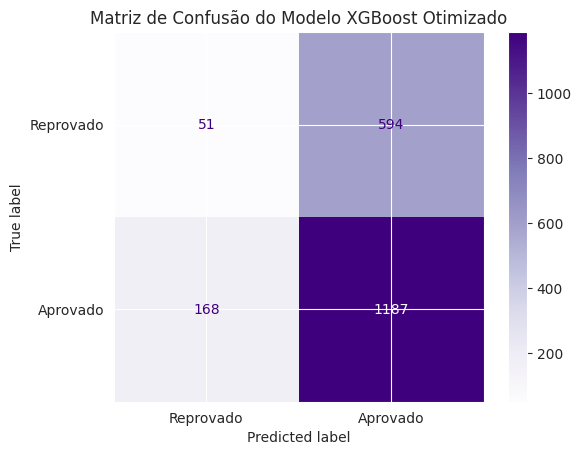

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Faz previsões com o melhor modelo encontrado
y_pred_final_otimizado = best_xgb_model.predict(X_test_scaled)

print(f"\n--- ANÁLISE FINAL DO MODELO OTIMIZADO COM XGBOOST ---")

# Relatório de Classificação Detalhado
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_final_otimizado, target_names=['Reprovado', 'Aprovado']))

# Matriz de Confusão Final
print("\nMatriz de Confusão:")
cm_final = confusion_matrix(y_test, y_pred_final_otimizado)
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['Reprovado', 'Aprovado'])
disp_final.plot(cmap=plt.cm.Purples) # Nova cor para o novo modelo
plt.title(f"Matriz de Confusão do Modelo XGBoost Otimizado")
plt.show()

### Converter em PKL

In [10]:
import joblib

# Este código usa as variáveis 'best_xgb_model' e 'scaler' que existem na memória do notebook
# para criar os arquivos físicos.

# Salva o melhor modelo XGBoost
joblib.dump(best_xgb_model, 'projeto_api/modelo_final_xgboost.pkl')

# Salva o scaler que foi treinado com os dados
joblib.dump(scaler, 'projeto_api/scaler_final.pkl')

print("Arquivos 'modelo_final_xgboost.pkl' e 'scaler_final.pkl' criados com sucesso!")

Arquivos 'modelo_final_xgboost.pkl' e 'scaler_final.pkl' criados com sucesso!
